In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Carga del modelo
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

c:\Users\juani\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 12636.03it/s]


In [8]:
# Crear 5 imágenes aleatorias y 5 textos relacionados
images = [Image.fromarray(np.uint8(np.random.rand(224, 224, 3) * 255)) for _ in range(5)]
texts = ["un perro corriendo", "una playa soleada", "un coche deportivo", "un bosque oscuro", "una pizza deliciosa"]

# Obtener embeddings
inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
with torch.no_grad():
    image_features = model.get_image_features(pixel_values=inputs['pixel_values'])
    text_features = model.get_text_features(input_ids=inputs['input_ids'])

# Normalización

image_features = model.get_image_features(pixel_values=inputs['pixel_values'])
text_features = model.get_text_features(input_ids=inputs['input_ids'])

print("Embeddings generados con éxito.")

Embeddings generados con éxito.


In [11]:
# Verificación de que ambos viven en el mismo espacio (misma dimensión)
print(f"Dimensión imagen: {image_features.pooler_output.shape}")
print(f"Dimensión texto: {text_features.pooler_output.shape}")

Dimensión imagen: torch.Size([5, 512])
Dimensión texto: torch.Size([5, 512])


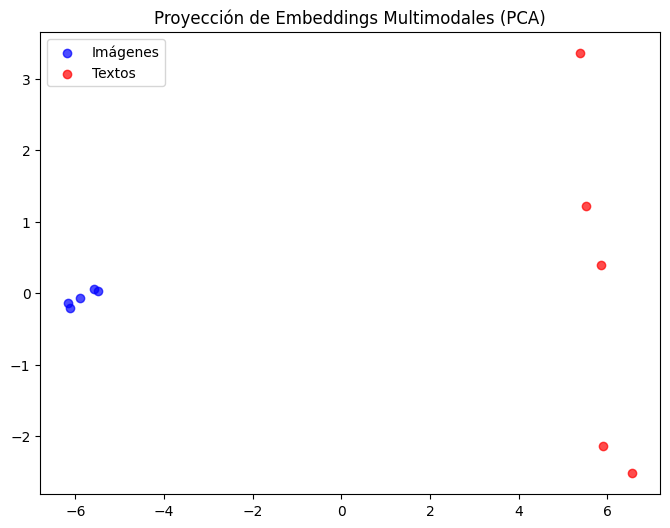

In [14]:
# Proyección a 2D y graficado
combined_features = torch.cat([image_features.pooler_output, text_features.pooler_output], dim=0).detach().cpu().numpy()
pca = PCA(n_components=2)
features_2d = pca.fit_transform(combined_features)

plt.figure(figsize=(8, 6))
plt.scatter(features_2d[:5, 0], features_2d[:5, 1], c='blue', label='Imágenes', alpha=0.7)
plt.scatter(features_2d[5:, 0], features_2d[5:, 1], c='red', label='Textos', alpha=0.7)
plt.legend()
plt.title("Proyección de Embeddings Multimodales (PCA)")
plt.show()

In [16]:
# Verificación de emparejamientos usando cosine similarity
# Verificación de emparejamientos usando cosine similarity
similarity_matrix = cosine_similarity(
    text_features.pooler_output.detach().cpu().numpy(),
    image_features.pooler_output.detach().cpu().numpy()
)

print("Matriz de similitud (Texto x Imagen):")
# Valores cercanos a 1 indican alta similitud
print(np.round(similarity_matrix, 3))

print("Matriz de similitud (Texto x Imagen):")
# Valores cercanos a 1 indican alta similitud
print(np.round(similarity_matrix, 3))

Matriz de similitud (Texto x Imagen):
[[0.214 0.215 0.215 0.215 0.209]
 [0.198 0.201 0.196 0.197 0.192]
 [0.202 0.201 0.201 0.2   0.198]
 [0.225 0.222 0.222 0.223 0.221]
 [0.208 0.209 0.203 0.205 0.198]]
Matriz de similitud (Texto x Imagen):
[[0.214 0.215 0.215 0.215 0.209]
 [0.198 0.201 0.196 0.197 0.192]
 [0.202 0.201 0.201 0.2   0.198]
 [0.225 0.222 0.222 0.223 0.221]
 [0.208 0.209 0.203 0.205 0.198]]
